# Introduction to Linear Regression: 

## Step 1: Transforming the Target Variable

Welcome to the first practical notebook of this series. In this guide, we will walk through a fundamental regression workflow using **Scikit-Learn**. Our primary objective is to learn the first steps for training a regression model. For this exercise, we will train a regression model that predicts the **median value** of households in  California in the 1990s, using several features of the house, like age of the house, number of total rooms, number of bedrooms, etc.

### Problem Statement
A problem statement is a concise description of the issue that needs to be addressed. It serves as the "North Star" for a data science project, ensuring that every technical decision, from data cleaning to model selection, aligns with the ultimate goal. Without a clear problem statement, data analysis can become a directionless exploration.

**Problem Statement for this exercise:**
> *"Can we accurately estimate the market value of a residential property based on its structural characteristics and neighborhood demographics?"*

By identifying the relationship between these features and the house price, we aim to build a model that provides reliable valuations for homeowners and real estate investors.

### The Data
We will use an open-sourced dataset used for a 1997 research paper "Sparse spatial autoregressions" by [Kelley Pace and Barry](https://doi.org/10.1016/S0167-7152(96)00140-X).

**Key Terminology:**

The value we want to predict is called the **target variable** (also known as the *Output*, *Response*, or *Dependent Variable*). In this dataset, the median value of households, stored under the `MedHouseVal` column, is our target variable.

The information that are used to predict the target variable are caled **predictor variables** (also known as *features*, *inputs*, *independent variables*, or covariates).

### Why Transform the Target Variable?

A common point of confusion in regression analysis is the assumption of normality. Technically, Linear Regression does not require the target variable itself to be normally distributed; however, it *does* assume that the **residuals (the errors between actual and predicted values) are normally distributed**. 

In practice, if the target variable is heavily skewed, the model often produces non-normal residuals. Therefore, our **first step is checking for normality of the target variable**. If it is skewed, we transform it to follow a normal distribution (the "Bell Curve") to ensure our model remains stable and reliable. At the end of the workflow, we apply **inverse transformations** so that the results remain interpretable in a real-world context (original USD).

### Learning Objectives
By the end of this lesson, you will be able to:
* **Assess Normality:** Understand why a normal distribution is preferred for the target variable in regression.
* **Transform Data:** Apply Log, Square Root, and Box-Cox transformations to address skewness.
* **Train and Evaluate:** Implement a linear regression model with polynomial features and feature scaling.
* **Inverse Transformation:** Map transformed predictions back to their original dollar values for meaningful interpretation.


---

## 0. Initial Setup, Data Loading and Inspection

Before building our model, we must prepare our environment. We begin by importing the standard data science stack: **NumPy**, **pandas**, and **Matplotlib**.

In [ ]:
#Uncomment and run in case you have not installed the required libraries.
#%pip install numpy, pandas, matplotlib, scipy, scikit-learn

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline

# Surpress warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

### Loading the Data

Now that our environment is ready, we will load the California Housing dataset directly using `sklearn.datasets.fetch_california_housing`.

In this step, we will:
1. Fetch the dataset (downloads on first run, then loads from local cache) into a pandas-compatible format.
2. Store the full table in `cali_housing_data` as a pandas DataFrame.
3. Gives a short description of the dataset.
4. Inspect the first few rows to verify the feature columns and target variable.

Notice that the target variable `MedHouseVal` will not be listed under the "Attribute Information."

> In case the direct download fails, you can download the [`california_housing_price.csv`](data/california_housing_price.csv) file from the `data` folder of this repo, and load it to this workspace (see the next code cell).

To learn with other datasets, visit this open-source data repositories from [Kaggle](https://www.kaggle.com/datasets?tags=13405-Linear+Regression), [UC Irvine Machine Learning](https://archive.ics.uci.edu/), and [scikit-learn](https://scikit-learn.org/stable/datasets/real_world.html).

In [42]:
import ssl, certifi, pandas as pd
from sklearn.datasets import fetch_california_housing

# Use certifi's CA bundle so urllib can validate HTTPS certificates across platforms.
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

california_data = fetch_california_housing(as_frame=True)
cali_housing_data = california_data.frame.copy()

print("Loaded California housing data with shape:", cali_housing_data.shape)
print(f"\nDescription of the dataset:\n{california_data.DESCR}")
cali_housing_data.head()

Loaded California housing data with shape: (20640, 9)

Description of the dataset:
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


**Important:**
> It is always a good practice to separate your data from the coding files; create a folder `data` in the same directory of your notebook and save this data file.

In [47]:
# In case you downloaded the `california_housing_price.csv` file and saved it in your `data` folder in the same working directory of this notebook, uncomment the following lines to load it to this workspace.

# with open('data/california_housing_price.csv', 'rb') as to_read:
#     cali_housing_data = pd.read_csv(to_read)

In [48]:
cali_housing_data.head(15)

,Unnamed: 0,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


---

## 1. Assessing Normality of the Target Variable

A key assumption in many linear regression contexts is that the target variable follows a **normal distribution** (also known as a Gaussian distribution or "Bell Curve"). When our target is normally distributed, the relationship between features and the target is often easier for the model to learn, leading to more reliable predictions.



To determine if our target variable (`MedHouseVal`) follows this distribution, we use two complementary methods:

1.  **Visual Inspection:** We plot a histogram to see if the data appears bell-shaped or if it is "skewed" (leaning to one side).
2.  **Statistical Testing:** We perform a **Normality Test** to calculate a p-value.

### 1.1. Visual Inspection: Plotting a histogram

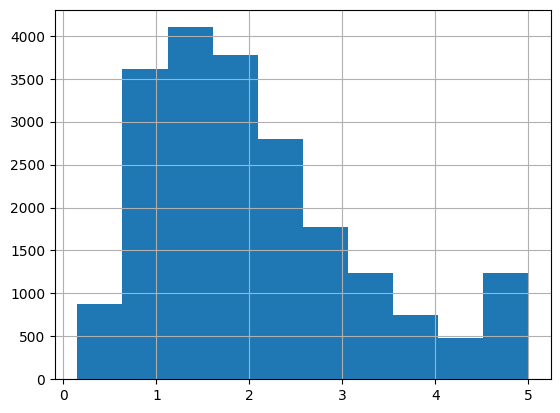

In [49]:
cali_housing_data.MedHouseVal.hist();

> The histogram does not look normal due to its skewness to the left and the right tail.


### 1.2. Using a Statistical Test `stats.normaltest`
We utilize the `normaltest` function from `scipy.stats`. This function tests the null hypothesis ($H_0$) that the sample comes from a normal distribution.

* **$p > 0.05$:** We fail to reject the null hypothesis. The data is likely normal.
* **$p < 0.05$:** We reject the null hypothesis. This indicates the data is **not** normally distributed and may benefit from a mathematical transformation.

In [82]:
from scipy.stats.mstats import normaltest # D'Agostino K^2 Test
p_val_original = normaltest(cali_housing_data.MedHouseVal.values)
print(p_val_original)

print(f"p-value for original target variable: {p_val_original.pvalue}")

NormaltestResult(statistic=np.float64(2430.931051066072), pvalue=np.float64(0.0))
p-value for original target variable: 0.0


> p-value is _extremely_ low. Our **y** variable which we will be dealing with is not normally distributed!

---


## 2. Transforming the Target Variable

When our initial normality test reveals a low p-value (specifically $p < 0.05$), it indicates that our target variable is skewed. This skewness can lead to heteroscedasticity or non-linear patterns in our residuals, which violates the assumptions of Linear Regression. 

To correct this, we apply mathematical transformations to "squeeze" the data into a more symmetric, bell-shaped distribution. In this section, we will compare three common techniques:

- **Log Transformation**
The **Log transformation** ($\ln(y)$) is a standard approach for data that is heavily right-skewed. While it often significantly improves the distribution and increases the p-value, it may not always reach the $0.05$ threshold required to assume normality.

- **Square Root Transformation**
The **Square Root transformation** ($\sqrt{y}$) is an alternative often used for count data or moderately skewed variables. However, in many real-world datasets, it often performs less effectively than the Log transformation.

- **The Box-Cox Transformation**
The **Box-Cox transformation** is a more sophisticated, parameterized power transformation. Rather than picking a fixed function, it searches for an optimal exponent, denoted as **Lambda ($\lambda$)**, that best transforms the data into a normal distribution.


The transformation is defined as:
$$y(\lambda) = \begin{cases} \frac{y^\lambda - 1}{\lambda} & \text{if } \lambda \neq 0 \\ \ln(y) & \text{if } \lambda = 0 \end{cases}$$

**Key Insights into Lambda ($\lambda$):**
* If $\lambda = 1$, no transformation is applied.
* If $\lambda = 0$, the transformation is equivalent to a **Log transformation**.
* If $\lambda = 0.5$, it is equivalent to a **Square Root transformation**.

When we execute `stats.boxcox()` in the following cells, the function will return both the **transformed array** and the **optimal $\lambda$** it discovered. We must save this $\lambda$ value, as it will be required later to perform the **Inverse Transformation** for our final predictions.

### 2.1. Log Transformation: A Conceptual Example

Before we apply transformations to our actual housing data, let's look at a conceptual example to see how the **Log Transformation** works in practice. 

The log transformation is particularly powerful for data that is "right-skewed"—where most values are small, but there are a few very large outliers (often following an exponential distribution). By taking the natural logarithm ($\ln$), we "pull in" these large values and stretch out the smaller ones, often resulting in a distribution that looks much more like a Bell Curve.

In the following code cell, we will:
1.  **Generate Synthetic Data:** Create 1,000 data points that follow an exponential distribution.
2.  **Visualize the Raw Data:** Observe the initial skewness in a histogram.
3.  **Apply `np.log`:** Transform the data and re-plot it.
4.  **Validate with `normaltest`:** Compare the p-value before and after the transformation to see if we successfully achieved a normal distribution.

*Note: In this case, because the data was generated exponentially, the log transformation should yield a near-perfect normal distribution with a high p-value.*

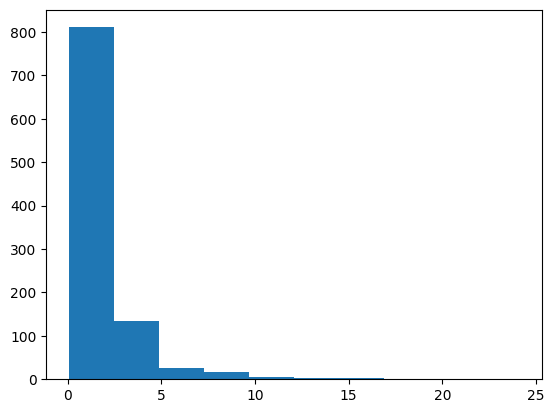

NormaltestResult(statistic=np.float64(867.5435476162099), pvalue=np.float64(4.123938971911598e-189))


In [88]:
data_exp = np.exp(np.random.normal(size=1000))
plt.hist(data_exp)
plt.show()
print(normaltest(data_exp))

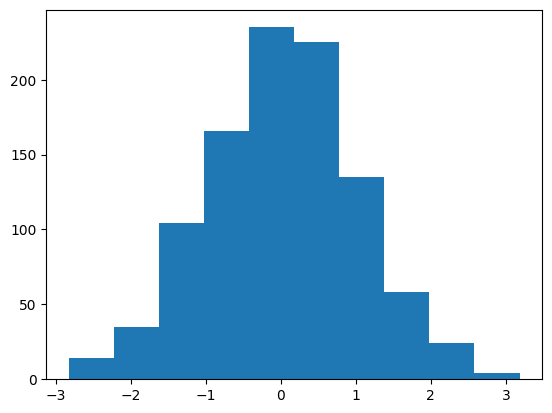

NormaltestResult(statistic=np.float64(0.3936876332424036), pvalue=np.float64(0.8213188996566809))


In [89]:
log_transformed_data = np.log(data_exp)
plt.hist(log_transformed_data)
plt.show()
print(normaltest(log_transformed_data))

### 2.2 Applying Log Transformation to the California Housing Data

Now that we have conceptually explored how the Log transformation works with synthetic data, let's apply this logic to our actual target variable: `MedHouseVal`. 

As we saw in the initial inspection, our house price data is skewed. To make it suitable for Linear Regression, we will systematically test different mathematical transformations to see which one brings our distribution closest to a "Bell Curve."

In the following cells, we will:
1.  **Apply Log Transformation:** Use `np.log()` on the `MedHouseVal` column and re-run the `normaltest`.
2.  **Apply Square Root Transformation:** Use `np.sqrt()` as an alternative and compare the resulting p-value.
3.  **Identify the Best Fit:** Look for the transformation that yields the highest p-value, even if it doesn't quite reach the $0.05$ threshold.


Pay close attention to the **p-value** outputs in the Python results below. You will notice that while both methods improve the distribution, the target variable may still remain "technically" non-normal. This is why we will eventually introduce the **Box-Cox** method in the next section to find an even more optimal solution.

p-value for log-transformed target variable: 8.432814311328483e-79


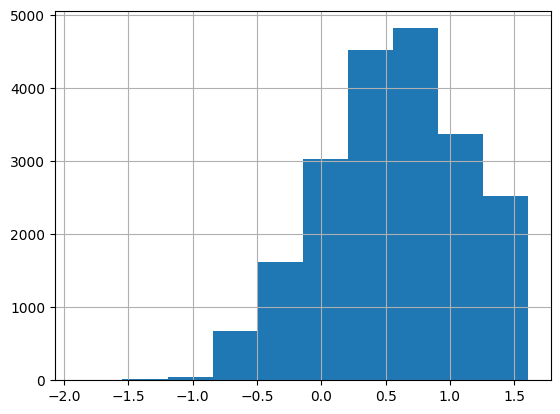

In [90]:
log_medv = np.log(cali_housing_data.MedHouseVal)
log_medv.hist();
p_val_log_medv = normaltest(log_medv)
print(f"p-value for log-transformed target variable: {p_val_log_medv.pvalue}")

> Conclusion: The output is closer to normal distribution, but still far away from being normally distributed.


### 2.3. Square root Transformation

The square root transformation is another transformation that can transform non-normally distributed data into normally distributed data:


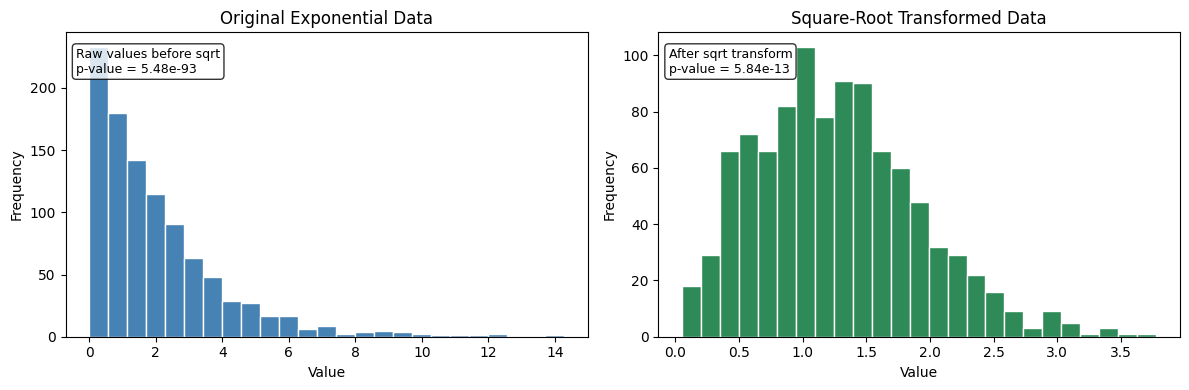

In [99]:
data = np.random.exponential(scale=2.0, size=1000)
data_sqrt_transformed = np.sqrt(data)

pval_original = normaltest(data).pvalue
pval_sqrt = normaltest(data_sqrt_transformed).pvalue

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(data, bins=25, color='steelblue', edgecolor='white')
axes[0].set_title('Original Exponential Data')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')
axes[0].text(
    0.02,
    0.95,
    f'Raw values before sqrt\np-value = {pval_original:.2e}',
    transform=axes[0].transAxes,
    va='top',
    fontsize=9,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

axes[1].hist(data_sqrt_transformed, bins=25, color='seagreen', edgecolor='white')
axes[1].set_title('Square-Root Transformed Data')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')
axes[1].text(
    0.02,
    0.95,
    f'After sqrt transform\np-value = {pval_sqrt:.2e}',
    transform=axes[1].transAxes,
    va='top',
    fontsize=9,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.tight_layout()
plt.show()

With an exponential sample, the square-root transform visibly reduces right skew.

It may still not be perfectly normal, but the distribution is closer to symmetric than the original.

### 2.4. Applying Square-root Transformation to the California Housing Data

Apply the square root transformation to the California Housing data target and test whether the result is normally distributed.

NormaltestResult(statistic=np.float64(851.8425227299578), pvalue=np.float64(1.0586355256007262e-185))


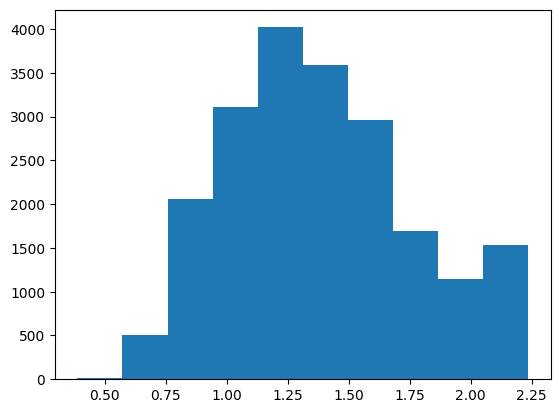

In [102]:
sqrt_medv = np.sqrt(cali_housing_data.MedHouseVal)
plt.hist(sqrt_medv)
print(normaltest(sqrt_medv))

### 2.5. Box-Cox Transformation: Optimal Power Transform

The **Box-Cox transformation** is the most sophisticated of the three methods we will explore. Unlike the Log or Square Root transformations, which apply a *fixed* mathematical function, Box-Cox is a **parametric** transformation. It searches for the optimal exponent $\lambda$ (Lambda) that minimizes the skewness of the distribution as much as possible.

It is formally defined as:

$$y_i(\lambda) = \begin{cases} \frac{y_i^{\lambda} - 1}{\lambda} & \text{if } \lambda \neq 0 \\ \ln(y_i) & \text{if } \lambda = 0 \end{cases}$$

You can think of it as a generalization of the square root function: while the square root fixes the exponent at $0.5$, Box-Cox searches for the exponent that works best for your specific data.

**Key Insights into Lambda ($\lambda$):**
* If $\lambda = 1$, no transformation is applied.
* If $\lambda = 0$, the result is equivalent to a **Log transformation**.
* If $\lambda = 0.5$, it is equivalent to a **Square Root transformation**.

In the following code cell, we will:
1. **Apply Box-Cox:** Run `scipy.stats.boxcox()` on `MedHouseVal` and retrieve the transformed array.
2. **Store $\lambda$:** Save the optimal lambda — we will need it later to perform the **inverse transformation** and recover predictions in their original unit.
3. **Compare Visually:** Plot the original and transformed distributions side-by-side as subplots.
4. **Validate with `normaltest`:** Confirm whether Box-Cox achieves a p-value above the $0.05$ normality threshold — and compare it against the Log and Square Root results.

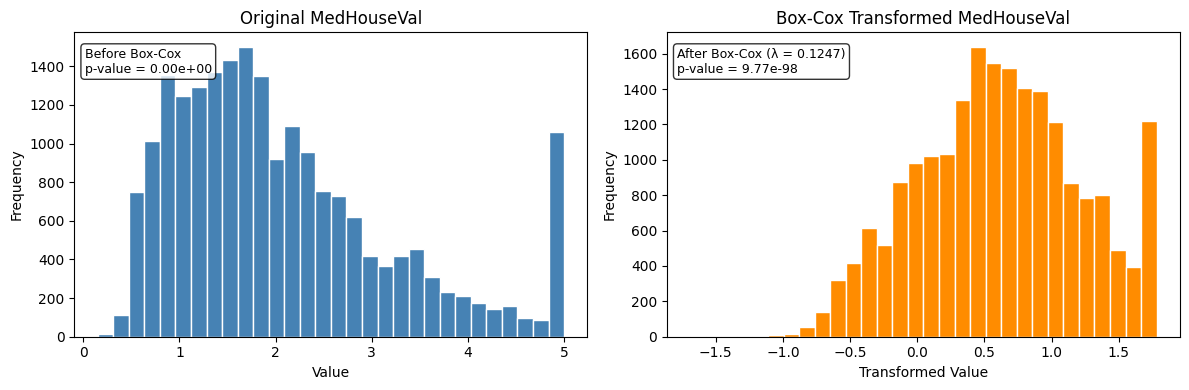

Optimal lambda (λ): 0.124748
p-value for Box-Cox transformed target variable: 9.77e-98


In [ ]:
from scipy.stats import boxcox

bc_result = boxcox(cali_housing_data.MedHouseVal)
boxcox_medv = bc_result[0]
lam = bc_result[1] # The optimal lambda value for the Box-Cox transformation

pval_original = normaltest(cali_housing_data.MedHouseVal.values).pvalue
pval_boxcox = normaltest(boxcox_medv).pvalue

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(cali_housing_data.MedHouseVal, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Original MedHouseVal')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')
axes[0].text(
    0.02, 0.95,
    f'Before Box-Cox\np-value = {pval_original:.2e}',
    transform=axes[0].transAxes,
    va='top',
    fontsize=9,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

axes[1].hist(boxcox_medv, bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Box-Cox Transformed MedHouseVal')
axes[1].set_xlabel('Transformed Value')
axes[1].set_ylabel('Frequency')
axes[1].text(
    0.02, 0.95,
    f'After Box-Cox (λ = {lam:.4f})\np-value = {pval_boxcox:.2e}',
    transform=axes[1].transAxes,
    va='top',
    fontsize=9,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.tight_layout()
plt.show()

print(f'Optimal lambda (λ): {lam:.6f}')
print(f'p-value for Box-Cox transformed target variable: {pval_boxcox:.2e}')

Neither Box-Cox nor Yeo-Johnson reached the normality threshold of $p > 0.05$ for `MedHouseVal`. This is expected for this dataset because the target is **censored** at 5.0 (equivalent to $500,000), which creates a structural spike in the distribution that smooth transformations cannot fully remove.

Even though strict normality was not achieved, these transformations still reduce skewness in most of the distribution and often make the regression fit more stable than using the raw target directly.

In the next section, we proceed to **Testing Regression** using the transformed target (Box-Cox), and later apply the inverse transformation so predictions can be interpreted in the original price scale.

---


## 3. Train and Evaluate Regression Models

Now that we have explored target transformations and selected a practical option (Box-Cox), we can move to the core supervised-learning workflow.

In this section, we will:
1. Define predictors (`X`) and target (`y`).
2. Create polynomial features to capture non-linear relationships.
3. Split data into training and testing sets.
4. Preprocess and transform the data.
5. Fit a Linear Regression model on transformed targets.
6. Evaluate model performance and interpret predictions in the original price scale using inverse transformation.

In [ ]:
# Import model, metrics, data split, and preprocessing tools for training and evaluation.
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (StandardScaler, 
                                   PolynomialFeatures)
from sklearn.metrics import r2_score

# Initialize a baseline linear regression estimator object.
lr = LinearRegression()

### 3.1. Define and load the predictor (X) and Target(y) variables

We separate the feature matrix from the outcome variable before model training:
- `X`: all input columns except `MedHouseVal`
- `y`: the target column (`MedHouseVal`) that we will transform for training

In [111]:
y_col = "MedHouseVal"
X = cali_housing_data.drop(y_col, axis=1)
y = cali_housing_data[y_col]

### 3.2. Create Polynomial Features

We increase the model's fit by adding interaction and squared terms using `PolynomialFeatures`.

This expands the feature space so linear regression can model non-linear relationships in the original variables.

Note the number of columns X_pf in not 9 like the original data, but 54. And thus, we added many features in order to add on complexity.

In [114]:
# Expand features to degree-2 polynomials (without adding a duplicate bias column).
pf = PolynomialFeatures(degree=2, include_bias=False)
X_pf = pf.fit_transform(X)

print("Shape of original features:", X.shape)
print("Shape of polynomial features:", X_pf.shape)

Shape of original features: (20640, 9)
Shape of polynomial features: (20640, 54)


### 3.3. Split the data into Training and Test Sets

The split ratio here is 0.7 and 0.3 which means we will assign **70%** data for training and **30%** data for testing. We use the random_state to pull out the testing values randomly, but we will keep it the same so that we get the same data for future iterations.


In [115]:
X_train, X_test, y_train, y_test = train_test_split(X_pf, y, test_size=0.3, random_state=12345)

### 3.4. Scale Training Features with `StandardScaler`

This step is going to calculate the mean value and the standard deviation for each one of the columns in `X_train`, ​and subtract the mean and ​divide by that standard deviation. This is how we normalize our training set. 

> Note that standardization must be fit using only the training data.

Later, we will apply `s.transform(X_test)` (not `fit_transform`) so the test set uses the same mean and standard deviation learned from training.

In [ ]:
s = StandardScaler()
X_train_s = s.fit_transform(X_train) # Set the standardized version to a new variable to avoid overwriting the original training features.

The `s` object is fitted on the training features, so it has learned the mean and standard deviation of each feature from the training data. We will use this same `s` object to standardize the test features, ensuring that both training and test features are standardized using the same parameters.

### 3.5. Transform `y_train` for regression stability

We now apply a target transformation to the training target before model fitting. Because Box-Cox performed best among our tested options, we will apply Box-Cox to `y_train` and save its lambda for inverse transformation later.

In [116]:
# Apply Box-Cox only on y_train.
bc_result2 = boxcox(y_train)
y_train_bc = bc_result2[0]

lam2 = bc_result2[1] # The optimal lambda value for the Box-Cox transformation on the training target variable. We will use this to inverse-transform predictions back to the original scale for evaluation.

The shapes of the transformed target variable and the standardized features should be the same in terms of number of samples (rows) for model training.

In [121]:
print(y_train_bc.shape)
print(X_train_s.shape)

(14448,)
(14448, 54)


### 3.6. Fit the linear regression model

- Fit the model on the standardized polynomial features and Box-Cox transformed target variable. After fitting, we will have a trained model that can predict the transformed target variable based on the input features.

- Standardize the test features using the same scaler fitted on the training features.

- Get predictions on the standardized test features in the Box-Cox transformed scale.

In [ ]:
lr.fit(X_train_s, y_train_bc)
X_test_s = s.transform(X_test)
y_pred_bc = lr.predict(X_test_s)

### 3.7. Apply inverse transformations to y_pred_bc 
This will enable us to compare the values of the target variable predicted by the model, `y_pred_bc`, with the actual target values in the test set `y_test`.

Every transformation has an inverse transformation. The inverse transformation of $f(x) = \sqrt{x}$ is $f^{-1}(x) = x^2$, for example. Box cox has an inverse transformation as well: notice that we have to pass in the lambda value that we found from before:

In [122]:
from scipy.special import inv_boxcox

In [127]:
print(inv_boxcox(boxcox_medv, lam)[:10])
print(cali_housing_data.MedHouseVal.values[:10])

[4.526 3.585 3.521 3.413 3.422 2.697 2.992 2.414 2.267 2.611]
[4.526 3.585 3.521 3.413 3.422 2.697 2.992 2.414 2.267 2.611]


Exactly the same, as we would hope!


#### Apply the inverse transformation to `y_pred_bc`.

In [128]:
y_pred_tran = inv_boxcox(y_pred_bc,lam2)

**Calculate the $R^2$ using the result of this inverse transformation and `y_test`.**

In [129]:
r2_score(y_test,y_pred_tran)

-0.04143261148690969

####Exercise: 

**Determine the $R^2$ of a LinearRegression without the box cox transformation.**

In [130]:
lr = LinearRegression()
lr.fit(X_train_s,y_train)
lr_pred = lr.predict(X_test_s)
r2_score(y_test,lr_pred)

0.01748418392358375